In [1]:
import numpy as np
import matplotlib.pyplot as plt

Proponer un modelo SIR, como el del ejercicio 10 pero con un delay en el paso
de susceptible a infectado. Resolver y comparar con el modelo del Ejercicio 11.

Modelo Ejercicio 10
$$
\frac{dS}{dt} = -\beta \frac{SI}{N}
$$

$$
\frac{dI}{dt} = \beta \frac{SI}{N} - \gamma I
$$

$$
\frac{dR}{dt} = \gamma I
$$

con $\beta$ y $\gamma$ las tasas de infección y recuperación respectivamente.

Modelo Ejercicio 11
$$
\frac{dS}{dt} = -\beta \frac{SI}{N}
$$

$$
\frac{dE}{dt} = \beta \frac{SI}{N} - \sigma E
$$

$$
\frac{dI}{dt} = \sigma E - \gamma I
$$

$$
\frac{dR}{dt} = \gamma I
$$

In [4]:
def sir_con_delay(beta, gamma, tau, N, S0, I0, R0, t0, tf, h):

    # Cantidad de pasos
    num_pasos = int((tf-t0) / h)
    t = np.linspace(t0, tf, num_pasos+1)

    # Cantidad de pasos RETARDO
    m = int(round(tau / h))

    if not np.isclose(m * h, tau):
        raise ValueError('Conviene elegir h tal que tau/h sea entero')
    
    # Soluciones 
    S = np.zeros(num_pasos+1)
    I = np.zeros(num_pasos+1)
    R = np.zeros(num_pasos+1)

    # Condiciones iniciales
    S[0] = S0
    I[0] = I0
    R[0] = R0

    def historia_S(t):
        return S0
    
    def historia_I(t):
        return I0
    
    def historia_R(t):
        return R0
    
    for n in range(num_pasos):
        tn = t[n]

        if n - m >=0:
            S_tau = S[n-m]
            I_tau = I[n-m]
        else:
            t_ret = tn - tau
            S_tau = historia_S(t_ret)
            I_tau = historia_I(t_ret)

        # Euler 
        dS = -beta * (S[n] * I[n]) / N
        dI = beta * (S_tau * I_tau) / N - gamma * I[n]
        dR = gamma * I[n]

        S[n+1] = S[n] + h * dS
        I[n+1] = I[n] + h * dI
        R[n+1] = R[n] + h * dR

    return t, S, I, R

In [6]:
def sistema(t, estado, beta, gamma, sigma, N):
    s, e, i, r = estado
    dSdt = -beta * (s*i)/N
    dEdt = beta * (s*i)/N - sigma * e
    dIdt = sigma * e - gamma * i
    dRdt = gamma * i

    return np.array([dSdt, dEdt, dIdt, dRdt])

def euler(s0, e0, i0, r0, beta, gamma, sigma, N, t0, tf, h):
    t_valores = [t0]
    s_valores = [s0]
    e_valores = [e0]
    i_valores = [i0]
    r_valores = [r0]

    t, s, e, i, r = t0, s0, e0, i0, r0

    while t < tf:
        estado = np.array([s, e, i, r])
        pendiente = sistema(t, estado, beta, gamma, sigma, N)
        
        estado = estado + h * pendiente
        s, e, i, r = estado

        t = t + h

        t_valores.append(t)
        s_valores.append(s)
        e_valores.append(e)
        i_valores.append(i)
        r_valores.append(r)

    return np.array(t_valores), np.array(s_valores), np.array(e_valores), np.array(i_valores), np.array(r_valores)

In [10]:
t_sir, s_sir, i_sir, r_sir = sir_con_delay(0.2, 0.1, 2, 10000, 9999, 1, 0, 0, 200, 0.1)
t_seir, s_seir, e_seir, i_seir, r_seir = euler(9999, 0, 1, 0, 0.4, 0.1, 0.5, 10000, 0, 200, 0.1)

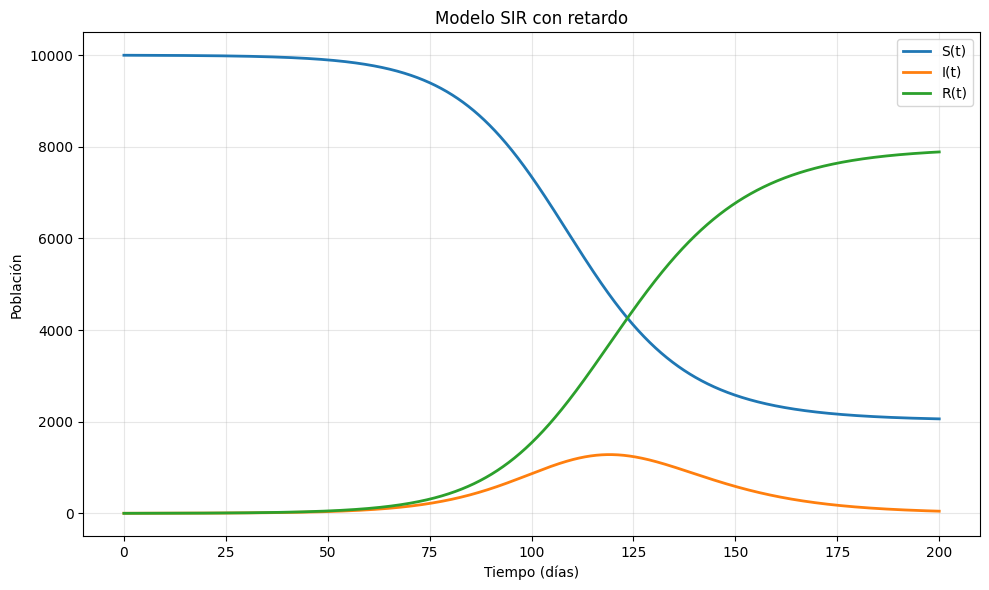

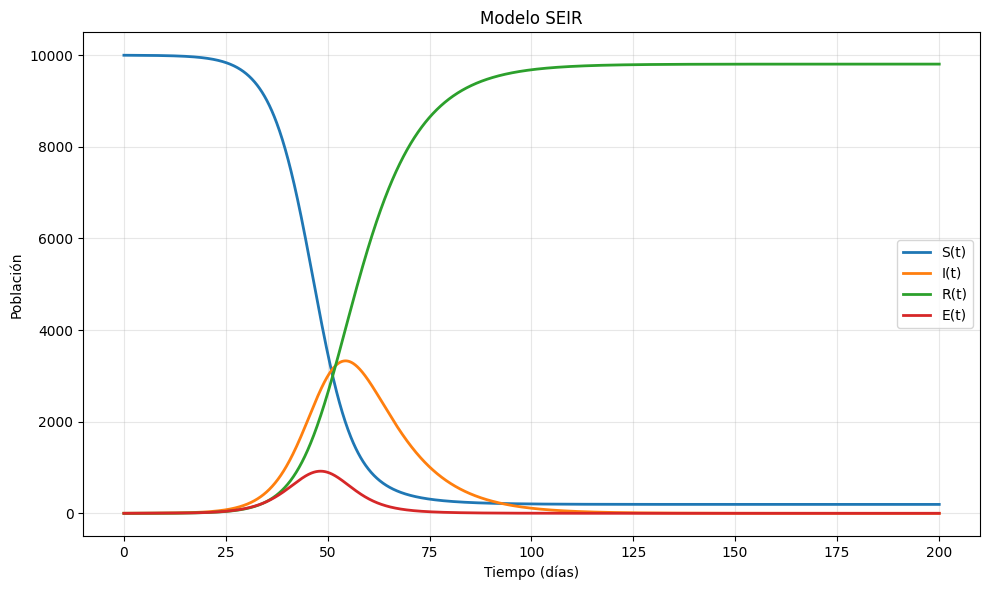

In [12]:
import matplotlib.pyplot as plt

# Gráfico SIR con delay
plt.figure(figsize=(10, 6))
plt.plot(t_sir, s_sir, label='S(t)', linewidth=2)
plt.plot(t_sir, i_sir, label='I(t)', linewidth=2)
plt.plot(t_sir, r_sir, label='R(t)', linewidth=2)

plt.title('Modelo SIR con retardo')
plt.xlabel('Tiempo (días)')
plt.ylabel('Población')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# Gráfico SEIR
plt.figure(figsize=(10, 6))
plt.plot(t_seir, s_seir, label='S(t)', linewidth=2)
plt.plot(t_seir, i_seir, label='I(t)', linewidth=2)
plt.plot(t_seir, r_seir, label='R(t)', linewidth=2)
plt.plot(t_seir, e_seir, label='E(t)', linewidth=2)

plt.title('Modelo SEIR')
plt.xlabel('Tiempo (días)')
plt.ylabel('Población')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()